# Image-Only Fashion Style Classification

## Objective
Fine-tune and evaluate two **image-only** baselines on **FashionStyle14** across **30 stratified random splits** (same seeds as the robustness template): frozen **CLIP ViT-B/32** and ImageNet-pretrained **ViT-Base patch16** (`vit_base_patch16_224` in timm), each with the same MLP head.

## Pipeline (end-to-end)
1. Resolve paths, load **30 seeds** from `FashionStyle14_v1/seeds_list.txt`, and set hyperparameters.
2. Check hardware (CPU vs CUDA), GPU memory, and pick a safe batch size with AMP on CUDA when available.
3. Load the full image list from `complete_dataset.csv`, derive **14** class labels, and keep only rows whose files exist on disk.
4. For **each seed**: create a stratified 70% / 15% / 15% train/val/test split (`random_state=seed`), build DataLoaders, initialize the model (model-init seed fixed at 42), train with early stopping, evaluate on the test set, and save artifacts under `results/image_only/<model>/seed_<seed>/`.
5. After all 30 runs per model: aggregate test metrics into `all_seeds_summary.csv` and print mean +/- std.
6. Learning curves are shown in-notebook only (`plt.show()`; not saved as image files).

## Inputs
| Input | Description |
|-------|-------------|
| `FashionStyle14_v1/complete_dataset.csv` | Full dataset: one relative image path per line (`dataset/<class>/...`). |
| `FashionStyle14_v1/seeds_list.txt` | List of 30 random seeds (1-500) for stratified train/val/test splits. |
| `FashionStyle14_v1/dataset/` | Image files referenced by `complete_dataset.csv`. |
| Pre-trained weights | `openai/clip-vit-base-patch32` (Transformers) and `vit_base_patch16_224` (timm). |

## Outputs (on disk)
Per-seed artifacts: **`results/image_only/<model_name>/seed_<seed>/`**

| File | Description |
|------|-------------|
| `best_model.pt` | Best validation macro-F1 checkpoint. |
| `training_history.json` | Per-epoch train/val loss and metrics. |
| `test_metrics.json` | Overall test accuracy, macro precision / recall / F1. |
| `per_class.csv` | Per-class columns: `class, acc, precision, recall, f1`. |

Aggregated: **`results/image_only/<model_name>/all_seeds_summary.csv`** (one row per seed).

**Figures:** learning curves are **displayed only** in the notebook (not saved as image files).

## Notes
- Code and comments are in **English** only.
- The notebook auto-detects whether the working directory is the repo root or `FusionStyle/`.


## 1. Configuration, imports, and paths


In [1]:
from __future__ import annotations

import json
import os
import random
import warnings
from pathlib import Path
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from transformers import CLIPModel, CLIPProcessor

warnings.filterwarnings("ignore", category=UserWarning)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# Training hyperparameters
LEARNING_RATE = 5e-5
BATCH_SIZE = 32
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
DROPOUT = 0.5
WEIGHT_DECAY = 1e-4
MODEL_INIT_SEED = 42  # fixed model weight init for every seed experiment
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
VIT_MODEL_NAME = "vit_base_patch16_224"
CONVNEXT_MODEL_NAME = "convnext_base"

random.seed(MODEL_INIT_SEED)
np.random.seed(MODEL_INIT_SEED)
torch.manual_seed(MODEL_INIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def load_seeds(seeds_file: Path) -> List[int]:
    if not seeds_file.is_file():
        raise FileNotFoundError(f"Missing seeds file: {seeds_file}")
    content = seeds_file.read_text(encoding="utf-8")
    import re

    matches = re.findall(r"Seed\s+(\d+)", content, flags=re.IGNORECASE)
    seeds = sorted({int(s) for s in matches if 1 <= int(s) <= 500})
    if len(seeds) != 30:
        print(f"Warning: expected 30 seeds, found {len(seeds)}")
        seeds = seeds[:30]
    return seeds


def resolve_paths() -> Tuple[Path, Path, Path]:
    '''Find FusionStyle root and FashionStyle14_v1 data folder.'''
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "FusionStyle", cwd.parent / "FusionStyle"]
    for root in candidates:
        data_dir = root / "FashionStyle14_v1"
        dataset_dir = data_dir / "dataset"
        has_splits = (data_dir / "train.csv").is_file() or (data_dir / "train_new.csv").is_file()
        if has_splits and dataset_dir.is_dir():
            results_root = root / "results" / "image_only"
            return root, data_dir, results_root
    raise FileNotFoundError(
        "Could not locate FashionStyle14_v1 with train (or train_new) CSV and dataset/. "
        "Open the notebook from the repo root or FusionStyle/."
    )


PROJECT_ROOT, DATA_DIR, RESULTS_ROOT = resolve_paths()
IMAGE_ROOT = DATA_DIR
SEEDS_FILE = DATA_DIR / "seeds_list.txt"
COMPLETE_CSV = DATA_DIR / "complete_dataset.csv"
SEEDS = load_seeds(SEEDS_FILE)
SEEDS = SEEDS[:10]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("IMAGE_ROOT / dataset exists:", (IMAGE_ROOT / "dataset").is_dir())
print(f"Loaded {len(SEEDS)} seeds:", SEEDS)

c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle
DATA_DIR: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\FashionStyle14_v1
IMAGE_ROOT / dataset exists: True
Loaded 10 seeds: [13, 14, 16, 17, 45, 48, 53, 58, 72, 102]


## 2. Hardware check and runtime settings


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    total_mem_gb = props.total_memory / (1024**3)
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {total_mem_gb:.2f} GB")
    # Reduce batch size on low-VRAM GPUs while keeping the notebook runnable
    if total_mem_gb < 8:
        BATCH_SIZE = 8
    elif total_mem_gb < 12:
        BATCH_SIZE = 16
    else:
        BATCH_SIZE = 32
else:
    print("CUDA not available; using CPU (training will be slow).")
    BATCH_SIZE = 8

print(f"Selected BATCH_SIZE: {BATCH_SIZE}")
print(f"Using AMP on CUDA: {use_amp}")


CUDA device: NVIDIA GeForce RTX 3060 Ti
Total GPU memory: 8.00 GB
Selected BATCH_SIZE: 8
Using AMP on CUDA: True


## 3. Load full dataset, labels, and stratified split helper


In [4]:
def normalize_rel_path(path_str: str) -> str:
    # complete_dataset.csv uses Windows backslashes; unify to forward slashes
    return str(path_str).strip().replace("\\", "/")


def load_complete_dataset(csv_path: Path) -> pd.DataFrame:
    lines = csv_path.read_text(encoding="utf-8").splitlines()
    rel = [ln.strip() for ln in lines if ln.strip()]
    df = pd.DataFrame({"rel_path": rel})
    df["rel_path"] = df["rel_path"].map(normalize_rel_path)
    df["style"] = df["rel_path"].str.split("/").str[1]
    df["abs_path"] = df["rel_path"].apply(lambda r: str((IMAGE_ROOT / r.replace("/", os.sep)).resolve()))
    df = df[df["abs_path"].map(os.path.isfile)].reset_index(drop=True)
    return df


df_full = load_complete_dataset(COMPLETE_CSV)
classes = sorted(df_full["style"].unique().tolist())
assert len(classes) == 14, f"Expected 14 classes, got {len(classes)}: {classes}"
style_to_idx = {s: i for i, s in enumerate(classes)}
num_classes = len(classes)

print("Full dataset size (existing files only):", len(df_full))
print("Number of classes:", num_classes)
print("Classes:", classes)
print("Data splits will be created per seed (10 experiments per model).")


def split_by_seed(df: pd.DataFrame, seed_value: int) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        df,
        test_size=(VAL_RATIO + TEST_RATIO),
        stratify=df["style"],
        random_state=seed_value,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        stratify=temp_df["style"],
        random_state=seed_value,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


Full dataset size (existing files only): 13212
Number of classes: 14
Classes: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Data splits will be created per seed (10 experiments per model).


## 4. PyTorch dataset and CLIP / ViT transforms


In [5]:
class FashionImageDataset(Dataset):
    '''Image paths + integer style labels.'''

    def __init__(self, frame: pd.DataFrame, style_to_idx: Dict[str, int], transform):
        self.frame = frame.reset_index(drop=True)
        self.style_to_idx = style_to_idx
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.frame.iloc[idx]
        path = row["abs_path"]
        style = row["style"]
        label = self.style_to_idx[style]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), color=(0, 0, 0))
        tensor = self.transform(img)
        return {"pixel_values": tensor, "label": label}


def build_clip_processor() -> CLIPProcessor:
    return CLIPProcessor.from_pretrained(CLIP_MODEL_ID)


def clip_image_transform(processor: CLIPProcessor):
    def _fn(img: Image.Image):
        px = processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)
        return px

    return _fn


def build_vit_transform():
    data_config = timm.data.resolve_data_config({}, model=VIT_MODEL_NAME, verbose=False)
    return timm.data.create_transform(**data_config, is_training=False)

def build_convnext_transform():
    data_config = timm.data.resolve_data_config({}, model=CONVNEXT_MODEL_NAME, verbose=False)
    return timm.data.create_transform(**data_config, is_training=False)

clip_processor = build_clip_processor()
clip_transform = clip_image_transform(clip_processor)
vit_transform = build_vit_transform()
convnext_transform = build_convnext_transform()
NUM_WORKERS = 0


def make_loaders(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    transform,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    train_ds = FashionImageDataset(train_df, style_to_idx, transform)
    val_ds = FashionImageDataset(val_df, style_to_idx, transform)
    test_ds = FashionImageDataset(test_df, style_to_idx, transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, val_loader, test_loader


print("Transforms ready. DataLoaders are built per seed inside the experiment loop.")
print("Batch size:", BATCH_SIZE)


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Transforms ready. DataLoaders are built per seed inside the experiment loop.
Batch size: 8


## 5. Model definitions


In [6]:
class CLIPImageClassifier(nn.Module):
    '''Frozen CLIP image tower + MLP head (512 -> 256 -> 128 -> num_classes).'''

    def __init__(self, clip: CLIPModel, num_classes: int, dropout: float = DROPOUT):
        super().__init__()
        self.clip = clip
        for p in self.clip.parameters():
            p.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(clip.config.projection_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            feats = self.clip.get_image_features(pixel_values=pixel_values)
        feats = feats.float()
        return self.head(feats)


class ViTImageClassifier(nn.Module):
    '''timm ViT backbone + same MLP pattern (768 -> 256 -> 128 -> num_classes).'''

    def __init__(self, num_classes: int, dropout: float = DROPOUT):
        super().__init__()
        self.backbone = timm.create_model(VIT_MODEL_NAME, pretrained=True, num_classes=0)
        in_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.backbone(x)
        return self.head(feats)

class ConvNeXtImageClassifier(nn.Module):
    '''
    timm ConvNeXt backbone + MLP head
    '''

    def __init__(self, num_classes: int, dropout: float = DROPOUT):
        super().__init__()

        self.backbone = timm.create_model(
            CONVNEXT_MODEL_NAME,
            pretrained=True,
            num_classes=0
        )

        in_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes),
        )

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        feats = self.backbone(pixel_values)
        return self.head(feats)

print("Model classes defined.")


Model classes defined.


## 6. Training, evaluation, and in-notebook learning curves


In [7]:
def evaluate(model: nn.Module, loader: DataLoader, criterion, device: torch.device, use_amp: bool) -> Tuple[float, Dict[str, float], np.ndarray, np.ndarray]:
    model.eval()
    total_loss = 0.0
    all_preds: List[int] = []
    all_labels: List[int] = []
    with torch.no_grad():
        for batch in loader:
            x = batch["pixel_values"].to(device, non_blocking=True)
            y = batch["label"].to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
                logits = model(x)
                loss = criterion(logits, y)
            total_loss += float(loss.item()) * y.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(y.cpu().numpy().tolist())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_p = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_r = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    metrics = {"loss": avg_loss, "accuracy": acc, "macro_precision": macro_p, "macro_recall": macro_r, "macro_f1": macro_f1}
    return avg_loss, metrics, np.array(all_preds), np.array(all_labels)


def train_one_epoch(model, loader, optimizer, criterion, device, use_amp) -> Tuple[float, float]:
    model.train()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp and device.type == "cuda")
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in loader:
        x = batch["pixel_values"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
            logits = model(x)
            loss = criterion(logits, y)
        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        total_loss += float(loss.item()) * y.size(0)
        preds = logits.argmax(dim=1)
        correct += int((preds == y).sum().item())
        total += int(y.size(0))
    return total_loss / max(total, 1), correct / max(total, 1)


def plot_learning_curves(history: Dict[str, Any], title: str) -> None:
    '''Display learning curves in the notebook only (no file saved).'''
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["val_macro_f1"], label="val macro F1")
    axes[1].plot(epochs, history["train_acc"], label="train acc", alpha=0.7)
    axes[1].plot(epochs, history["val_acc"], label="val acc", alpha=0.7)
    axes[1].set_title("Metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def set_model_init_seed() -> None:
    random.seed(MODEL_INIT_SEED)
    np.random.seed(MODEL_INIT_SEED)
    torch.manual_seed(MODEL_INIT_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def train_image_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    out_dir: Path,
    model_name: str,
    seed_value: int,
    device: torch.device,
    use_amp: bool,
    plot_curves: bool = True,
) -> Dict[str, Any]:
    out_dir.mkdir(parents=True, exist_ok=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "train_acc": [], "val_acc": []}
    best_f1 = -1.0
    best_state = None
    patience_left = EARLY_STOPPING_PATIENCE

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, use_amp)
        val_loss, val_metrics, _, _ = evaluate(model, val_loader, criterion, device, use_amp)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_metrics["accuracy"])

        print(
            f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_metrics['accuracy']:.4f} macroF1 {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            patience_left = EARLY_STOPPING_PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    torch.save(model.state_dict(), out_dir / "best_model.pt")
    with open(out_dir / "training_history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)

    _, test_metrics, test_preds, test_labels = evaluate(model, test_loader, criterion, device, use_amp)

    # Per-class metrics (14 classes):
    # - acc: per-class accuracy = TP / (TP + FN) (equivalent to recall in one-vs-rest view)
    # - precision/recall/f1: macro per-class computation
    per_class_precision = precision_score(test_labels, test_preds, average=None, zero_division=0)
    per_class_recall = recall_score(test_labels, test_preds, average=None, zero_division=0)
    per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)

    per_class_rows = []
    for i, cls in enumerate(classes):
        per_class_rows.append(
            {
                "class": cls,
                "acc": float(per_class_recall[i]),
                "precision": float(per_class_precision[i]),
                "recall": float(per_class_recall[i]),
                "f1": float(per_class_f1[i]),
            }
        )

    per_class_df = pd.DataFrame(per_class_rows, columns=["class", "acc", "precision", "recall", "f1"])

    with open(out_dir / "test_metrics.json", "w", encoding="utf-8") as f:
        json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)

    per_class_csv_path = out_dir / "per_class.csv"
    per_class_df.to_csv(per_class_csv_path, index=False, encoding="utf-8")

    # Print overall + per-class summary
    print(f"\n[{model_name} | seed {seed_value}] Test metrics:", test_metrics)
    print(f"[{model_name} | seed {seed_value}] Per-class metrics (saved to {per_class_csv_path}):")
    print(per_class_df.to_string(index=False))

    if plot_curves:
        plot_learning_curves(history, title=f"Learning curves — {model_name} (seed {seed_value})")

    return {
        "seed": seed_value,
        "history": history,
        "test_metrics": test_metrics,
        "per_class_csv": str(per_class_csv_path),
        "out_dir": str(out_dir),
    }


def run_robustness_for_model(
    model_name: str,
    build_model_fn,
    transform,
    clip_backbone: CLIPModel | None = None,
) -> pd.DataFrame:
    model_root = RESULTS_ROOT / model_name
    model_root.mkdir(parents=True, exist_ok=True)
    rows: List[Dict[str, Any]] = []

    for seed_idx, seed_value in enumerate(SEEDS, start=1):
        seed_dir = model_root / f"seed_{seed_value}"
        done_marker = seed_dir / "test_metrics.json"
        if done_marker.is_file():
            print(f"[{model_name}] Seed {seed_value} ({seed_idx}/{len(SEEDS)}): skip (already done)")
            with open(done_marker, encoding="utf-8") as f:
                cached = json.load(f)
            rows.append({"seed": seed_value, **cached})
            continue

        print("=" * 70)
        print(f"[{model_name}] Experiment {seed_idx}/{len(SEEDS)} | data split seed = {seed_value}")
        print("=" * 70)

        train_df, val_df, test_df = split_by_seed(df_full, seed_value)
        print(f"  Split sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

        train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df, transform)

        set_model_init_seed()
        if model_name == "clip":
            assert clip_backbone is not None
            model = build_model_fn(clip_backbone).to(device)
        else:
            model = build_model_fn().to(device)

        result = train_image_model(
            model,
            train_loader,
            val_loader,
            test_loader,
            out_dir=seed_dir,
            model_name=model_name,
            seed_value=seed_value,
            device=device,
            use_amp=use_amp,
            plot_curves=True,
        )
        rows.append({"seed": seed_value, **{k: float(v) for k, v in result["test_metrics"].items()}})

        del model, train_loader, val_loader, test_loader
        if device.type == "cuda":
            torch.cuda.empty_cache()

    summary_df = pd.DataFrame(rows)
    summary_path = model_root / "all_seeds_summary.csv"
    summary_df.to_csv(summary_path, index=False, encoding="utf-8")
    print(f"\n[{model_name}] Saved summary: {summary_path}")
    if len(summary_df) > 0:
        print(
            f"[{model_name}] macro_f1 mean +/- std: "
            f"{summary_df['macro_f1'].mean():.4f} +/- {summary_df['macro_f1'].std():.4f}"
        )
    return summary_df


print("Training utilities ready.")


Training utilities ready.


## 7. CLIP robustness: 10 seeds


In [35]:
clip_backbone = CLIPModel.from_pretrained(CLIP_MODEL_ID)


def build_clip_model(backbone: CLIPModel) -> CLIPImageClassifier:
    return CLIPImageClassifier(backbone, num_classes=num_classes)


summary_clip = run_robustness_for_model(
    model_name="clip",
    build_model_fn=build_clip_model,
    transform=clip_transform,
    clip_backbone=clip_backbone,
)

[clip] Seed 13 (1/10): skip (already done)
[clip] Seed 14 (2/10): skip (already done)
[clip] Seed 16 (3/10): skip (already done)
[clip] Seed 17 (4/10): skip (already done)
[clip] Seed 45 (5/10): skip (already done)
[clip] Seed 48 (6/10): skip (already done)
[clip] Seed 53 (7/10): skip (already done)
[clip] Seed 58 (8/10): skip (already done)
[clip] Seed 72 (9/10): skip (already done)
[clip] Seed 102 (10/10): skip (already done)

[clip] Saved summary: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\image_only\clip\all_seeds_summary.csv
[clip] macro_f1 mean +/- std: 0.8374 +/- 0.0094


## 8. ViT robustness: 10 seeds


In [36]:
def build_vit_model() -> ViTImageClassifier:
    return ViTImageClassifier(num_classes=num_classes)


summary_vit = run_robustness_for_model(
    model_name="vit",
    build_model_fn=build_vit_model,
    transform=vit_transform,
)

[vit] Seed 13 (1/10): skip (already done)
[vit] Seed 14 (2/10): skip (already done)
[vit] Seed 16 (3/10): skip (already done)
[vit] Seed 17 (4/10): skip (already done)
[vit] Seed 45 (5/10): skip (already done)
[vit] Seed 48 (6/10): skip (already done)
[vit] Seed 53 (7/10): skip (already done)
[vit] Seed 58 (8/10): skip (already done)
[vit] Seed 72 (9/10): skip (already done)
[vit] Seed 102 (10/10): skip (already done)

[vit] Saved summary: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\image_only\vit\all_seeds_summary.csv
[vit] macro_f1 mean +/- std: 0.5892 +/- 0.0470


## 9. ConvNeXt robustness: 10 seeds

[convnext] Experiment 1/10 | data split seed = 13
  Split sizes: train=9248, val=1982, test=1982
Downloading: "https://dl.fbaipublicfiles.com/convnext/convnext_base_1k_224_ema.pth" to C:\Users\Sandy/.cache\torch\hub\checkpoints\convnext_base_1k_224_ema.pth
Epoch 01 | train loss 1.8873 acc 0.3772 | val loss 1.1372 acc 0.6478 macroF1 0.6385
Epoch 02 | train loss 0.9542 acc 0.6807 | val loss 0.8257 acc 0.7255 macroF1 0.7282
Epoch 03 | train loss 0.4886 acc 0.8459 | val loss 0.8510 acc 0.7417 macroF1 0.7449
Epoch 04 | train loss 0.2752 acc 0.9225 | val loss 0.9685 acc 0.7497 macroF1 0.7497
Epoch 05 | train loss 0.1454 acc 0.9628 | val loss 0.9918 acc 0.7588 macroF1 0.7639
Epoch 06 | train loss 0.1050 acc 0.9740 | val loss 1.2117 acc 0.7487 macroF1 0.7475
Epoch 07 | train loss 0.0815 acc 0.9811 | val loss 1.0838 acc 0.7704 macroF1 0.7726
Epoch 08 | train loss 0.0624 acc 0.9843 | val loss 1.4075 acc 0.7225 macroF1 0.7212
Epoch 09 | train loss 0.0558 acc 0.9872 | val loss 1.3702 acc 0.7598 ma

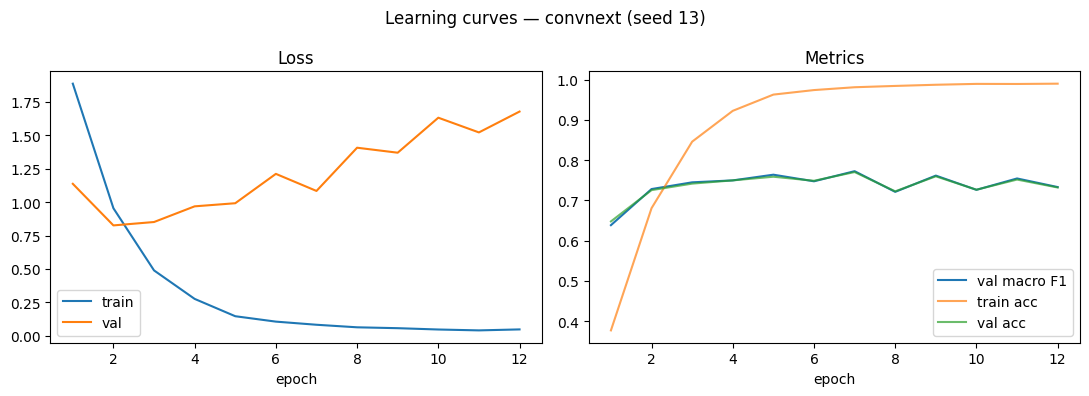

[convnext] Experiment 2/10 | data split seed = 14
  Split sizes: train=9248, val=1982, test=1982
Epoch 01 | train loss 1.9001 acc 0.3621 | val loss 1.1948 acc 0.6241 macroF1 0.6142
Epoch 02 | train loss 0.9761 acc 0.6707 | val loss 0.8839 acc 0.7064 macroF1 0.7079
Epoch 03 | train loss 0.5203 acc 0.8414 | val loss 0.8132 acc 0.7472 macroF1 0.7487
Epoch 04 | train loss 0.2716 acc 0.9248 | val loss 0.8944 acc 0.7614 macroF1 0.7634
Epoch 05 | train loss 0.1513 acc 0.9626 | val loss 1.0820 acc 0.7553 macroF1 0.7566
Epoch 06 | train loss 0.0967 acc 0.9779 | val loss 1.1666 acc 0.7558 macroF1 0.7612
Epoch 07 | train loss 0.0714 acc 0.9815 | val loss 1.2316 acc 0.7523 macroF1 0.7541
Epoch 08 | train loss 0.0513 acc 0.9893 | val loss 1.3803 acc 0.7558 macroF1 0.7611
Epoch 09 | train loss 0.0419 acc 0.9904 | val loss 1.5604 acc 0.7432 macroF1 0.7482
Early stopping triggered.

[convnext | seed 14] Test metrics: {'loss': 0.8774628621177404, 'accuracy': 0.7547931382441978, 'macro_precision': 0.769

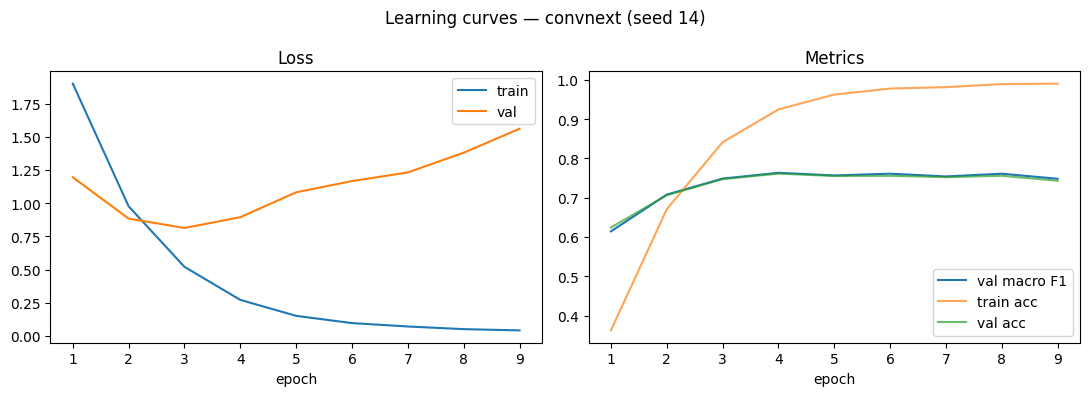

[convnext] Experiment 3/10 | data split seed = 16
  Split sizes: train=9248, val=1982, test=1982
Epoch 01 | train loss 1.8674 acc 0.3818 | val loss 1.1998 acc 0.6191 macroF1 0.5924
Epoch 02 | train loss 0.9624 acc 0.6835 | val loss 0.8400 acc 0.7180 macroF1 0.7136
Epoch 03 | train loss 0.5159 acc 0.8428 | val loss 0.8322 acc 0.7442 macroF1 0.7387
Epoch 04 | train loss 0.2639 acc 0.9292 | val loss 0.8717 acc 0.7694 macroF1 0.7709
Epoch 05 | train loss 0.1532 acc 0.9620 | val loss 0.9530 acc 0.7528 macroF1 0.7543
Epoch 06 | train loss 0.0964 acc 0.9798 | val loss 1.1764 acc 0.7608 macroF1 0.7631
Epoch 07 | train loss 0.0790 acc 0.9815 | val loss 1.1420 acc 0.7770 macroF1 0.7776
Epoch 08 | train loss 0.0628 acc 0.9859 | val loss 1.2788 acc 0.7553 macroF1 0.7583
Epoch 09 | train loss 0.0632 acc 0.9846 | val loss 1.1293 acc 0.7760 macroF1 0.7763
Epoch 10 | train loss 0.0455 acc 0.9897 | val loss 1.2363 acc 0.7760 macroF1 0.7769
Epoch 11 | train loss 0.0322 acc 0.9932 | val loss 1.3644 acc 0

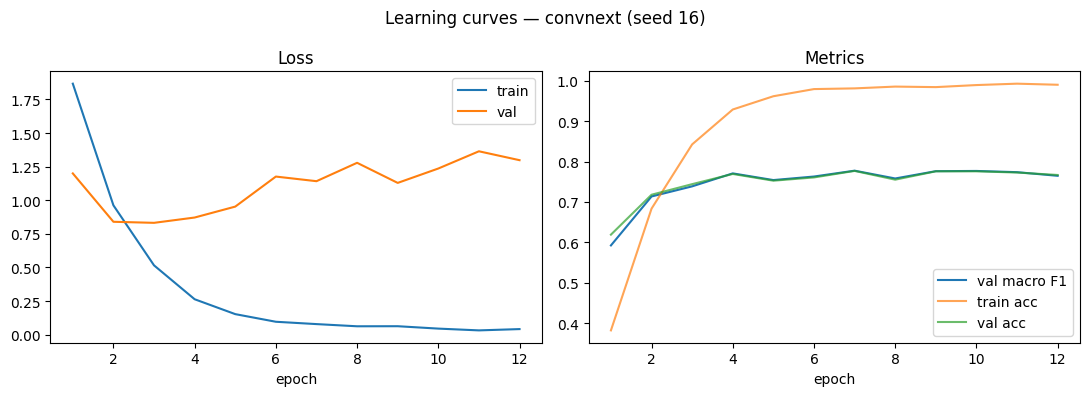

[convnext] Experiment 4/10 | data split seed = 17
  Split sizes: train=9248, val=1982, test=1982
Epoch 01 | train loss 1.8940 acc 0.3638 | val loss 1.1647 acc 0.6403 macroF1 0.6280
Epoch 02 | train loss 0.9958 acc 0.6637 | val loss 0.8347 acc 0.7306 macroF1 0.7193
Epoch 03 | train loss 0.5426 acc 0.8279 | val loss 0.9487 acc 0.7170 macroF1 0.7199
Epoch 04 | train loss 0.2852 acc 0.9184 | val loss 0.9669 acc 0.7407 macroF1 0.7409
Epoch 05 | train loss 0.1547 acc 0.9593 | val loss 1.1648 acc 0.7351 macroF1 0.7386
Epoch 06 | train loss 0.0950 acc 0.9803 | val loss 1.1584 acc 0.7659 macroF1 0.7690
Epoch 07 | train loss 0.0739 acc 0.9821 | val loss 1.2544 acc 0.7528 macroF1 0.7548
Epoch 08 | train loss 0.0690 acc 0.9836 | val loss 1.2443 acc 0.7624 macroF1 0.7648
Epoch 09 | train loss 0.0490 acc 0.9881 | val loss 1.3311 acc 0.7598 macroF1 0.7641
Epoch 10 | train loss 0.0471 acc 0.9884 | val loss 1.4588 acc 0.7427 macroF1 0.7496
Epoch 11 | train loss 0.0365 acc 0.9928 | val loss 1.3574 acc 0

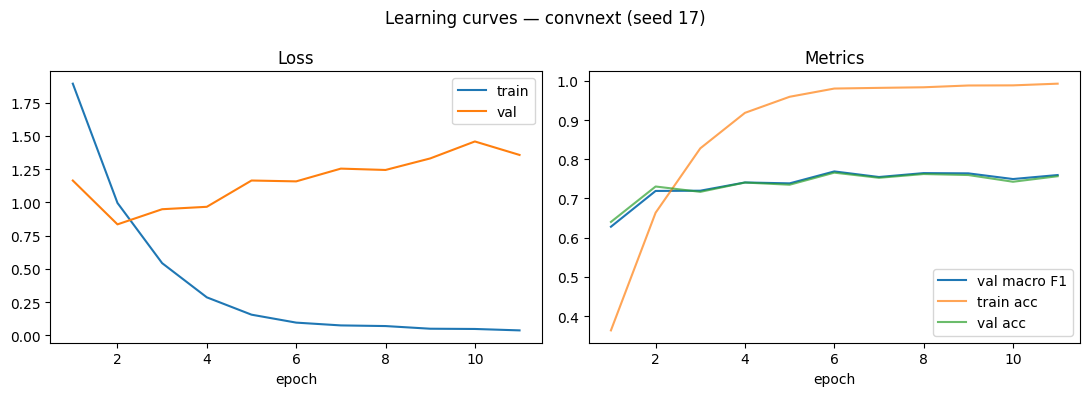

[convnext] Experiment 5/10 | data split seed = 45
  Split sizes: train=9248, val=1982, test=1982
Epoch 01 | train loss 1.8818 acc 0.3799 | val loss 1.1492 acc 0.6266 macroF1 0.6131
Epoch 02 | train loss 0.9337 acc 0.6912 | val loss 0.7702 acc 0.7462 macroF1 0.7473
Epoch 03 | train loss 0.4845 acc 0.8556 | val loss 0.7955 acc 0.7634 macroF1 0.7649
Epoch 04 | train loss 0.2503 acc 0.9325 | val loss 0.8640 acc 0.7785 macroF1 0.7802
Epoch 05 | train loss 0.1379 acc 0.9662 | val loss 1.1338 acc 0.7533 macroF1 0.7556
Epoch 06 | train loss 0.0964 acc 0.9791 | val loss 1.0737 acc 0.7785 macroF1 0.7807
Epoch 07 | train loss 0.0729 acc 0.9824 | val loss 1.1518 acc 0.7699 macroF1 0.7714
Epoch 08 | train loss 0.0588 acc 0.9871 | val loss 1.2391 acc 0.7714 macroF1 0.7723
Epoch 09 | train loss 0.0474 acc 0.9876 | val loss 1.2444 acc 0.7624 macroF1 0.7633
Epoch 10 | train loss 0.0442 acc 0.9897 | val loss 1.2844 acc 0.7785 macroF1 0.7805
Epoch 11 | train loss 0.0505 acc 0.9870 | val loss 1.3568 acc 0

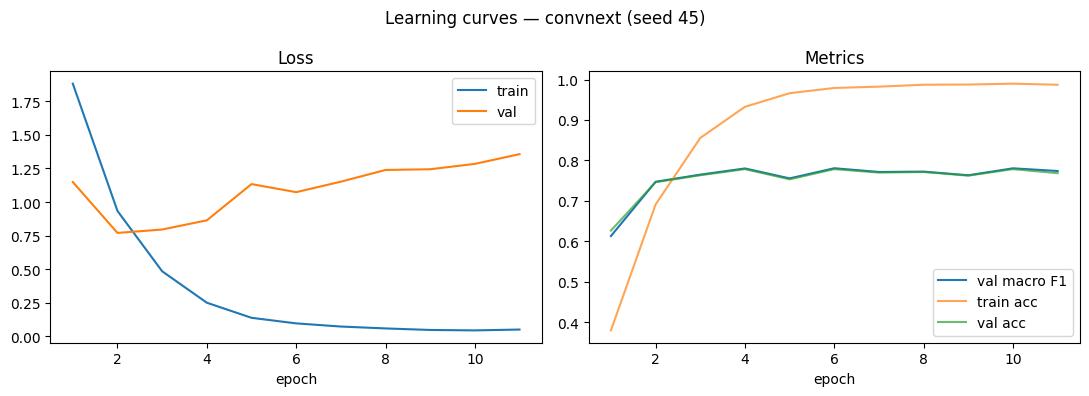

[convnext] Experiment 6/10 | data split seed = 48
  Split sizes: train=9248, val=1982, test=1982
Epoch 01 | train loss 1.8910 acc 0.3747 | val loss 1.1434 acc 0.6297 macroF1 0.6156
Epoch 02 | train loss 0.9800 acc 0.6770 | val loss 0.8364 acc 0.7270 macroF1 0.7256
Epoch 03 | train loss 0.4974 acc 0.8452 | val loss 0.8222 acc 0.7477 macroF1 0.7498
Epoch 04 | train loss 0.2782 acc 0.9213 | val loss 0.8911 acc 0.7639 macroF1 0.7681
Epoch 05 | train loss 0.1477 acc 0.9623 | val loss 1.0954 acc 0.7523 macroF1 0.7563
Epoch 06 | train loss 0.1078 acc 0.9746 | val loss 1.3004 acc 0.7381 macroF1 0.7392
Epoch 07 | train loss 0.0880 acc 0.9800 | val loss 1.2516 acc 0.7497 macroF1 0.7502
Epoch 08 | train loss 0.0634 acc 0.9861 | val loss 1.3477 acc 0.7583 macroF1 0.7651
Epoch 09 | train loss 0.0465 acc 0.9899 | val loss 1.3995 acc 0.7644 macroF1 0.7680
Early stopping triggered.

[convnext | seed 48] Test metrics: {'loss': 0.8555964589961, 'accuracy': 0.768920282542886, 'macro_precision': 0.7785448

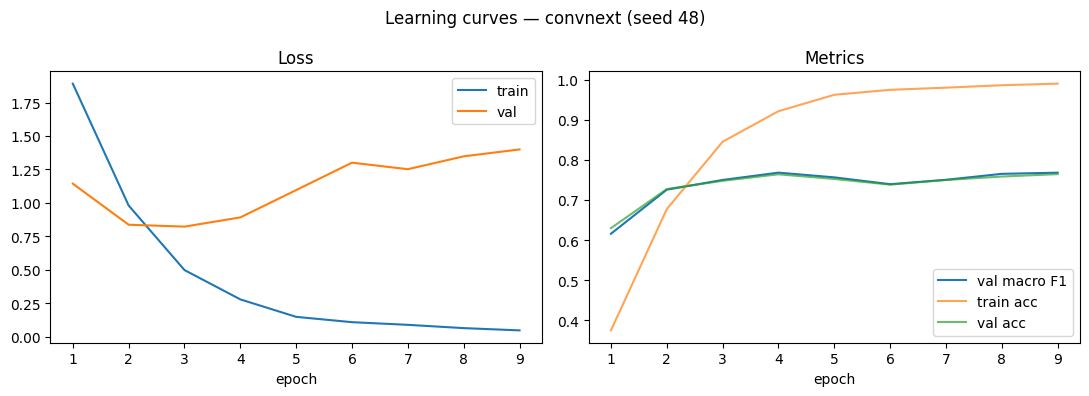

[convnext] Experiment 7/10 | data split seed = 53
  Split sizes: train=9248, val=1982, test=1982
Epoch 01 | train loss 1.8944 acc 0.3681 | val loss 1.1584 acc 0.6282 macroF1 0.6214
Epoch 02 | train loss 0.9785 acc 0.6694 | val loss 0.8108 acc 0.7306 macroF1 0.7314
Epoch 03 | train loss 0.5011 acc 0.8433 | val loss 0.8137 acc 0.7381 macroF1 0.7418
Epoch 04 | train loss 0.2790 acc 0.9214 | val loss 0.9489 acc 0.7568 macroF1 0.7591
Epoch 05 | train loss 0.1450 acc 0.9646 | val loss 1.0478 acc 0.7578 macroF1 0.7575
Epoch 06 | train loss 0.0931 acc 0.9773 | val loss 1.1942 acc 0.7578 macroF1 0.7600
Epoch 07 | train loss 0.0867 acc 0.9797 | val loss 1.2283 acc 0.7286 macroF1 0.7320
Epoch 08 | train loss 0.0676 acc 0.9838 | val loss 1.2737 acc 0.7598 macroF1 0.7616
Epoch 09 | train loss 0.0529 acc 0.9877 | val loss 1.3218 acc 0.7619 macroF1 0.7615
Epoch 10 | train loss 0.0487 acc 0.9882 | val loss 1.2805 acc 0.7563 macroF1 0.7590
Epoch 11 | train loss 0.0403 acc 0.9905 | val loss 1.4702 acc 0

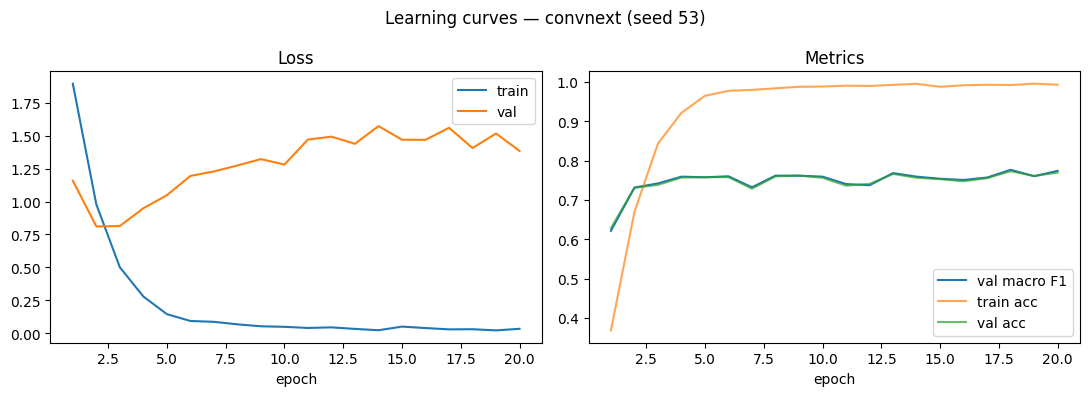

[convnext] Experiment 8/10 | data split seed = 58
  Split sizes: train=9248, val=1982, test=1982
Epoch 01 | train loss 1.8793 acc 0.3753 | val loss 1.1598 acc 0.6171 macroF1 0.5998
Epoch 02 | train loss 0.9700 acc 0.6731 | val loss 0.8529 acc 0.7159 macroF1 0.7110
Epoch 03 | train loss 0.5131 acc 0.8380 | val loss 0.8258 acc 0.7553 macroF1 0.7552
Epoch 04 | train loss 0.2685 acc 0.9243 | val loss 0.9918 acc 0.7321 macroF1 0.7226
Epoch 05 | train loss 0.1586 acc 0.9602 | val loss 1.0989 acc 0.7523 macroF1 0.7535
Epoch 06 | train loss 0.0997 acc 0.9750 | val loss 1.0948 acc 0.7563 macroF1 0.7583
Epoch 07 | train loss 0.0670 acc 0.9836 | val loss 1.2959 acc 0.7538 macroF1 0.7551
Epoch 08 | train loss 0.0565 acc 0.9876 | val loss 1.3488 acc 0.7573 macroF1 0.7593
Epoch 09 | train loss 0.0571 acc 0.9857 | val loss 1.3105 acc 0.7649 macroF1 0.7681
Epoch 10 | train loss 0.0558 acc 0.9871 | val loss 1.3671 acc 0.7482 macroF1 0.7530
Epoch 11 | train loss 0.0504 acc 0.9881 | val loss 1.6202 acc 0

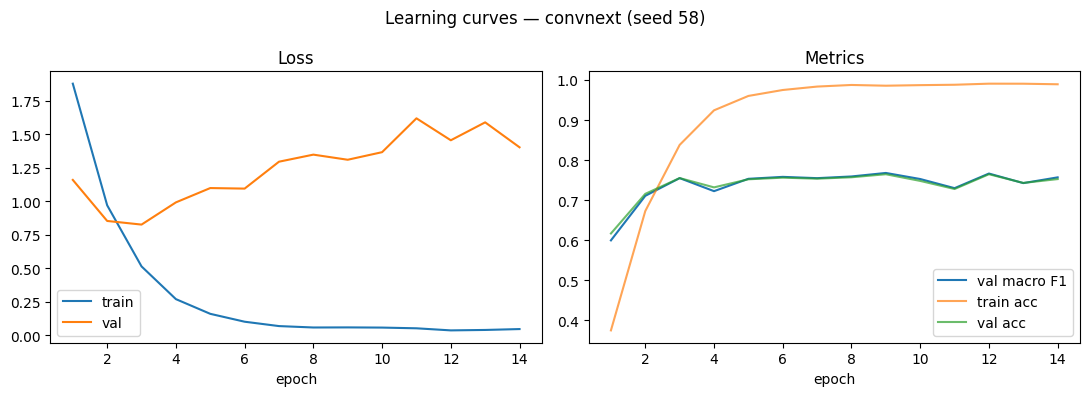

[convnext] Experiment 9/10 | data split seed = 72
  Split sizes: train=9248, val=1982, test=1982
Epoch 01 | train loss 1.9003 acc 0.3667 | val loss 1.2065 acc 0.6070 macroF1 0.5905
Epoch 02 | train loss 0.9951 acc 0.6638 | val loss 0.8617 acc 0.7109 macroF1 0.7010
Epoch 03 | train loss 0.5194 acc 0.8413 | val loss 0.8048 acc 0.7578 macroF1 0.7581
Epoch 04 | train loss 0.2865 acc 0.9187 | val loss 0.8930 acc 0.7634 macroF1 0.7633
Epoch 05 | train loss 0.1520 acc 0.9596 | val loss 1.0366 acc 0.7704 macroF1 0.7723
Epoch 06 | train loss 0.0907 acc 0.9782 | val loss 1.1906 acc 0.7583 macroF1 0.7609
Epoch 07 | train loss 0.0772 acc 0.9808 | val loss 1.2572 acc 0.7553 macroF1 0.7586
Epoch 08 | train loss 0.0597 acc 0.9879 | val loss 1.3450 acc 0.7371 macroF1 0.7351
Epoch 09 | train loss 0.0593 acc 0.9869 | val loss 1.3993 acc 0.7503 macroF1 0.7552
Epoch 10 | train loss 0.0446 acc 0.9901 | val loss 1.3955 acc 0.7588 macroF1 0.7621
Early stopping triggered.

[convnext | seed 72] Test metrics: {

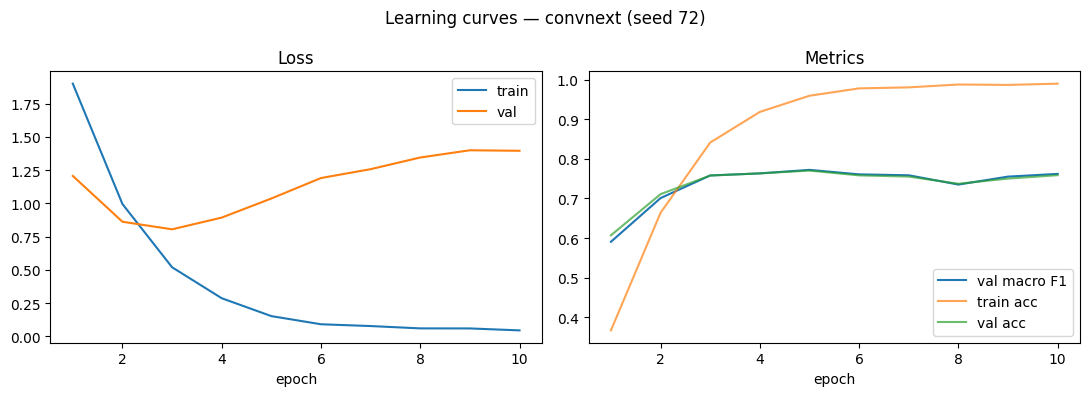

[convnext] Experiment 10/10 | data split seed = 102
  Split sizes: train=9248, val=1982, test=1982
Epoch 01 | train loss 1.8720 acc 0.3813 | val loss 1.1308 acc 0.6287 macroF1 0.6126
Epoch 02 | train loss 0.9464 acc 0.6872 | val loss 0.8741 acc 0.7038 macroF1 0.7028
Epoch 03 | train loss 0.4948 acc 0.8454 | val loss 0.8952 acc 0.7336 macroF1 0.7360
Epoch 04 | train loss 0.2546 acc 0.9281 | val loss 1.0432 acc 0.7291 macroF1 0.7344
Epoch 05 | train loss 0.1496 acc 0.9630 | val loss 1.0992 acc 0.7528 macroF1 0.7531
Epoch 06 | train loss 0.0812 acc 0.9826 | val loss 1.2597 acc 0.7543 macroF1 0.7557
Epoch 07 | train loss 0.0847 acc 0.9792 | val loss 1.2890 acc 0.7366 macroF1 0.7375
Epoch 08 | train loss 0.0668 acc 0.9855 | val loss 1.4052 acc 0.7402 macroF1 0.7407
Epoch 09 | train loss 0.0473 acc 0.9890 | val loss 1.4794 acc 0.7482 macroF1 0.7506
Epoch 10 | train loss 0.0527 acc 0.9875 | val loss 1.5489 acc 0.7306 macroF1 0.7325
Epoch 11 | train loss 0.0421 acc 0.9912 | val loss 1.5071 acc

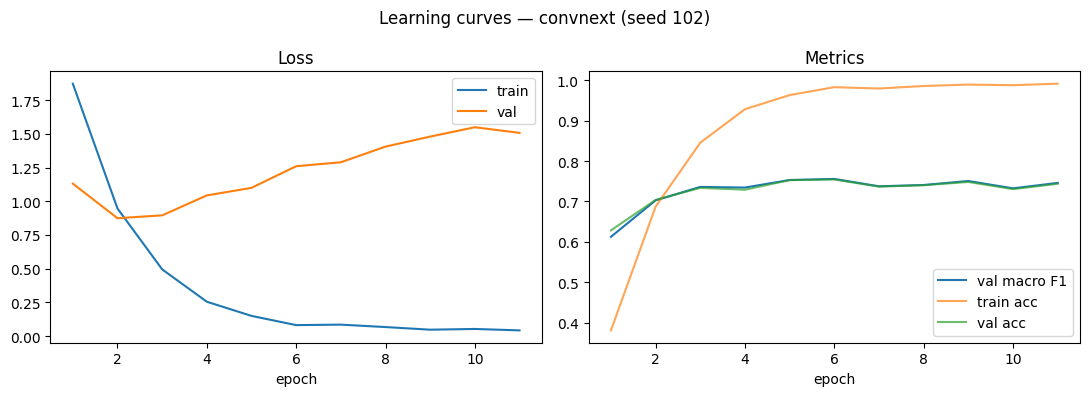


[convnext] Saved summary: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\image_only\convnext\all_seeds_summary.csv
[convnext] macro_f1 mean +/- std: 0.7694 +/- 0.0075


In [8]:
def build_convnext_model() -> ConvNeXtImageClassifier:
    return ConvNeXtImageClassifier(num_classes=num_classes)


summary_convnext = run_robustness_for_model(
    model_name="convnext",
    build_model_fn=build_convnext_model,
    transform=convnext_transform,
)

## Aggregate comparison (10 seeds)


In [9]:
metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]


def summarize_10_seeds(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    rows = []
    for col in metric_cols:
        if col not in df.columns:
            continue
        rows.append(
            {
                "model": model_name,
                "metric": col,
                "mean": float(df[col].mean()),
                "std": float(df[col].std()),
                "min": float(df[col].min()),
                "max": float(df[col].max()),
            }
        )
    return pd.DataFrame(rows)


clip_path = RESULTS_ROOT / "clip" / "all_seeds_summary.csv"
vit_path = RESULTS_ROOT / "vit" / "all_seeds_summary.csv"
convnext_path = RESULTS_ROOT / "convnext" / "all_seeds_summary.csv"

print("CLIP per-seed summary:", clip_path)
print("ViT per-seed summary:", vit_path)

if clip_path.is_file() and vit_path.is_file() and convnext_path.is_file():
    clip_df = pd.read_csv(clip_path)
    vit_df = pd.read_csv(vit_path)
    convnext_df = pd.read_csv(convnext_path)
    agg = pd.concat([summarize_10_seeds(clip_df, "clip"), summarize_10_seeds(vit_df, "vit"), summarize_10_seeds(convnext_df, "convnext"), summarize_10_seeds(convnext_df, "convnext")], ignore_index=True)
    print("\n10-seed test metrics (mean +/- std):")
    print(agg.to_string(index=False))
else:
    print("Run section 7 and 8 first to generate all_seeds_summary.csv files.")

CLIP per-seed summary: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\image_only\clip\all_seeds_summary.csv
ViT per-seed summary: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\image_only\vit\all_seeds_summary.csv

10-seed test metrics (mean +/- std):
   model          metric     mean      std      min      max
    clip        accuracy 0.837336 0.009410 0.824924 0.856206
    clip macro_precision 0.838236 0.008718 0.828695 0.857114
    clip    macro_recall 0.838551 0.009605 0.826424 0.857429
    clip        macro_f1 0.837406 0.009411 0.826267 0.856891
     vit        accuracy 0.588446 0.046534 0.527750 0.694753
     vit macro_precision 0.610223 0.047523 0.539043 0.718220
     vit    macro_recall 0.587289 0.045825 0.530075 0.692866
     vit        macro_f1 0.589236 0.047033 0.525650 0.696943
convnext        accuracy 0.767104 0.007608 0.754793 0.774975
convnext macro_precision 0.781033 0.011256 0.765578 0.798765
convnext    macro_recall 0.766277 0.007500 0.755150 0.777051
convnext